# 🔬 NIMT Data Science Workshop — Solution Notebook (เฉลย)
### การวิเคราะห์ข้อมูลสถาบันมาตรวิทยาแห่งชาติ — เฉลยสมบูรณ์

---

📌 **สมุดบันทึกนี้คือเฉลยสมบูรณ์ของ `nimt_eda_exercise.ipynb`**  
**This notebook is the complete solution for `nimt_eda_exercise.ipynb`.**

---

## 🎯 โจทย์ / Business Problem
> **"ต้องการเพิ่มรายได้จากการให้บริการสอบเทียบร้อยละ 10 ใน 1 ปี พร้อมวิเคราะห์แนวโน้ม ค้นหาข้อพิรุธ และพยากรณ์รายได้อนาคต"**
>
> **"Increase calibration service revenue by 10% in 1 year. Analyse trends, detect anomalies, and forecast future revenue."**

---
## 📦 ส่วนที่ 0: นำเข้าไลบรารี / Section 0: Import Libraries

In [1]:
# ✅ Solution — Section 0: Import Libraries
import os
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import silhouette_score, r2_score, mean_absolute_error

warnings.filterwarnings('ignore')
print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


---
## 📖 ส่วนที่ 1: อ่านพจนานุกรมข้อมูล / Section 1: Read Data Dictionary

| คอลัมน์ | ความหมาย |
|---|---|
| ORGEDESC | ชื่อฝ่ายงาน / Department name |
| IN_OUT | IN=ภายใน, OUT=ภายนอก / IN=internal, OUT=external |
| DESCRIPTION | ชื่อเครื่องมือ / Instrument name |
| CODEX | รหัสราคาสอบเทียบ / Price code |
| TOTALFEE | ค่าธรรมเนียม (บาท) / Fee (THB) |
| RECEIVEDDATE | วันรับเครื่อง / Date received |
| DUEDATE | วันกำหนดเสร็จ / Due date |
| DATECLOSE | วันเสร็จจริง / Actual completion date |
| PERIODDAY | จำนวนวันสอบเทียบ / Days for calibration |
| SERVICE | ประเภทบริการ / Service type |

In [2]:
# ✅ Solution — Section 1: Read Data Dictionary
path_dict = r"E:\DGA_ALL\DGA_2\Metrology_Department\for_final\data\Datadic สถาบันมาตรวิทยาแห่งชาติ.csv"

if os.path.exists(path_dict):
    df_dict = pd.read_csv(path_dict)
    display(df_dict)
else:
    print("❌ ไม่พบไฟล์ Data Dictionary / Data Dictionary file not found")

,ชื่อ Filed,คำบรรยายชื่อ Field,Datatype,ขนาด
0,ORGEDESC,ชื่อฝ่าย,Varchar2,20
1,IN_OUT,ประเภทการสอบเทียบ In คือ ภาย ใน สอบเทียบ กันเ...,Varchar2,5
2,DESCRIPTION,ชื่อเครื่องมือ,Varchar2,70
3,CODEX,รหัส ราคา ของการ สอบ เทียบ อุปกรณ์ชิ้นนั้น,Varchar2,15
4,TOTALFEE,ราคาสอบเทียบ ครั้งนั้น,float,"10,2"
5,RECEIVEDDATE,วันที่ได้รับเครื่องมือจากลูกค้า,date,NaN
6,DUEDATE,วันที่กำหนดเสร็จ,date,NaN
7,DATECLOSE,วันเสร็จจริง,date,NaN
8,PERIODDAY,จำนานวันที่ใช้ในการสอบเทียบ,int,4
9,SERVICE,ประเภทบริการ,Varchar2,20


---
## 🗂️ ส่วนที่ 2: โหลดและสำรวจข้อมูล / Section 2: Load & Explore Data

In [3]:
# ✅ Solution — Section 2.1: Load main dataset
path_data = r"E:\DGA_ALL\DGA_2\Metrology_Department\for_final\data\ข้อมูลสถาบันมาตรวิทยาแห่งชาติ2.csv"
df = pd.read_csv(path_data, low_memory=False)

print(f"📊 ขนาดข้อมูล / Data shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

📊 ขนาดข้อมูล / Data shape: 61,286 rows × 10 columns


In [4]:
# ✅ Solution — Section 2.2: Preview data
display(df.head())

,ORGEDESC,IN_OUT,DESCRIPTION,CODEX,TOTALFEE,RECEIVEDDATE,DUEDATE,DATECLOSE,PERIODDAY,SERVICE
0,Electrical Metrology Department,OUT,Hight Voltage Digital Meter,NaN,20250.0,13-03-2017,NaN,24-03-2017,11,Measurement at NIMT
1,Electrical Metrology Department,OUT,Lightning impulse Voltage Measuring System,NaN,26250.0,09-03-2017,NaN,24-03-2017,15,Measurement at NIMT
2,Thermometry Metrology Department,IN,ALMEMO,NaN,5630.0,23-03-2017,NaN,27-03-2017,4,Measurement at NIMT
3,Thermometry Metrology Department,IN,Humidity and Thermometer Recorder,NaN,5630.0,23-03-2017,NaN,27-03-2017,4,NaN
4,Thermometry Metrology Department,IN,Humidity and Thermometer Recorder,NaN,5630.0,23-03-2017,NaN,27-03-2017,4,Measurement at NIMT


In [5]:
# ✅ Solution — Section 2.3: Check data structure
print("=== df.info() ===")
df.info()

=== df.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61286 entries, 0 to 61285
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ORGEDESC      61286 non-null  object 
 1   IN_OUT        61286 non-null  object 
 2   DESCRIPTION   61272 non-null  object 
 3   CODEX         57629 non-null  object 
 4   TOTALFEE      61286 non-null  float64
 5   RECEIVEDDATE  61286 non-null  object 
 6   DUEDATE       60627 non-null  object 
 7   DATECLOSE     61286 non-null  object 
 8   PERIODDAY     61286 non-null  int64  
 9   SERVICE       61274 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 4.7+ MB


In [6]:
# ✅ Solution — Section 2.4: Check missing values
missing = pd.DataFrame({
    'Missing_Count': df.isna().sum(),
    'Missing_%': (df.isna().sum() / len(df) * 100).round(2)
})
# แสดงเฉพาะคอลัมน์ที่มีค่าว่าง / Show only columns with missing values
display(missing[missing['Missing_Count'] > 0])

,Missing_Count,Missing_%
DESCRIPTION,14,0.02
CODEX,3657,5.97
DUEDATE,659,1.08
SERVICE,12,0.02


In [7]:
# ✅ Solution — Section 2.5: Descriptive statistics
display(df[['TOTALFEE', 'PERIODDAY']].describe().T)

,count,mean,std,min,25%,50%,75%,max
TOTALFEE,61286.0,15132.070399,22310.212831,0.0,3750.0,8750.0,19000.0,1074140.0
PERIODDAY,61286.0,42.275756,51.481251,-2.0,15.0,28.0,50.0,1614.0


---
## 🧹 ส่วนที่ 3: ทำความสะอาดข้อมูล / Section 3: Data Cleaning

In [8]:
# ✅ Solution — Section 3.1: Clean ORGEDESC (BUG-002: double whitespace)
# ก่อนแก้ไข — ตรวจสอบชื่อฝ่ายงาน
print("=== Before cleaning ===")
print(df['ORGEDESC'].unique())

# Step 1: ตัดช่องว่างหน้า-หลัง
df['ORGEDESC'] = df['ORGEDESC'].astype(str).str.strip()

# Step 2: ลดช่องว่างซ้ำซ้อนภายใน (BUG-002)
df['ORGEDESC'] = df['ORGEDESC'].str.replace(r'  +', ' ', regex=True)

print("\n=== After cleaning ===")
print(df['ORGEDESC'].unique())
print(f"\nจำนวนฝ่ายงาน / Unique departments: {df['ORGEDESC'].nunique()}")

=== Before cleaning ===
['Electrical  Metrology Department' 'Thermometry Metrology Department'
 'Chemical Metrology  Department' 'Dimensional Metrology Department'
 'Mechanical  Metrology Department' 'Acoustic and Vibration'
 'Innovation and Measuring Devices Development Group'
 'Medical Metrology Program']

=== After cleaning ===
['Electrical Metrology Department' 'Thermometry Metrology Department'
 'Chemical Metrology Department' 'Dimensional Metrology Department'
 'Mechanical Metrology Department' 'Acoustic and Vibration'
 'Innovation and Measuring Devices Development Group'
 'Medical Metrology Program']

จำนวนฝ่ายงาน / Unique departments: 8


In [9]:
# ✅ Solution — Section 3.2: Clean SERVICE and IN_OUT
df['SERVICE'] = df['SERVICE'].astype(str).str.strip().str.replace(r'\r\n', '', regex=True)
df['SERVICE'] = df['SERVICE'].replace({'On Site': 'On site', 'nan': 'Unknown'}).fillna('Unknown')
df['IN_OUT'] = df['IN_OUT'].astype(str).str.strip()

print("SERVICE unique values:", df['SERVICE'].unique())
print("IN_OUT unique values:", df['IN_OUT'].unique())

SERVICE unique values: ['Measurement at NIMT' 'Unknown' 'Reference Materials' 'On site']
IN_OUT unique values: ['OUT' 'IN']


In [10]:
# ✅ Solution — Section 3.3: Standardize DESCRIPTION
def clean_description(desc):
    """Normalize instrument names to consistent standard forms."""
    if not isinstance(desc, str):
        return 'Unknown'
    desc = desc.strip()

    # LIDAR Speed Gun group
    if re.search(r'LIDAR SPEED\s*GUN|ตรวจจับความเร็ว.*LIDAR', desc, re.IGNORECASE) or 'LIDAR GUN' in desc.upper():
        return 'กล้องตรวจจับความเร็วชนิดมือถือ LIDAR SPEED GUN'

    # Speed Radar group
    if re.search(r'speed radar\s*\(station[a-z\s]*\)', desc, re.IGNORECASE):
        return 'Speed Radar (Stationary)'

    # Medical equipment groups
    if re.search(r'Vital\s*Sign[s]?\s*Simulator', desc, re.IGNORECASE):
        return 'Vital Signs Simulator'
    if re.search(r'NIBP\s*Simulator', desc, re.IGNORECASE):
        return 'NIBP Simulator'
    if re.search(r'Solar\s*Simulator', desc, re.IGNORECASE):
        return 'Solar Simulator'
    if re.search(r'Infusion\s*(Pump|Device)\s*Analyzer', desc, re.IGNORECASE):
        return 'Infusion Pump Analyzer'
    if re.search(r'Gas\s*Flow\s*Analyzer', desc, re.IGNORECASE):
        return 'Gas Flow Analyzer'

    return desc

df['DESCRIPTION'] = df['DESCRIPTION'].fillna('Unknown').astype(str).apply(clean_description)
print("✅ DESCRIPTION cleaned! Total unique instruments:", df['DESCRIPTION'].nunique())

✅ DESCRIPTION cleaned! Total unique instruments: 15802


In [11]:
# ✅ Solution — Section 3.4: Convert date columns
df['RECEIVED_DT'] = pd.to_datetime(df['RECEIVEDDATE'], dayfirst=True, errors='coerce')
df['CLOSE_DT']   = pd.to_datetime(df['DATECLOSE'],    dayfirst=True, errors='coerce')
df['DUE_DT']     = pd.to_datetime(df['DUEDATE'],      dayfirst=True, errors='coerce')

# สกัดปีและเดือน / Extract year and month
df['RECV_YEAR']  = df['RECEIVED_DT'].dt.year
df['RECV_MONTH'] = df['RECEIVED_DT'].dt.month

print("✅ Dates converted!")
print(df[['RECEIVEDDATE', 'RECEIVED_DT', 'RECV_YEAR', 'RECV_MONTH']].head())

✅ Dates converted!
  RECEIVEDDATE RECEIVED_DT  RECV_YEAR  RECV_MONTH
0   13-03-2017  2017-03-13       2017           3
1   09-03-2017  2017-03-09       2017           3
2   23-03-2017  2017-03-23       2017           3
3   23-03-2017  2017-03-23       2017           3
4   23-03-2017  2017-03-23       2017           3


---
## 📈 ส่วนที่ 4: วิเคราะห์ข้อมูลเชิงสำรวจ (EDA) / Section 4: EDA

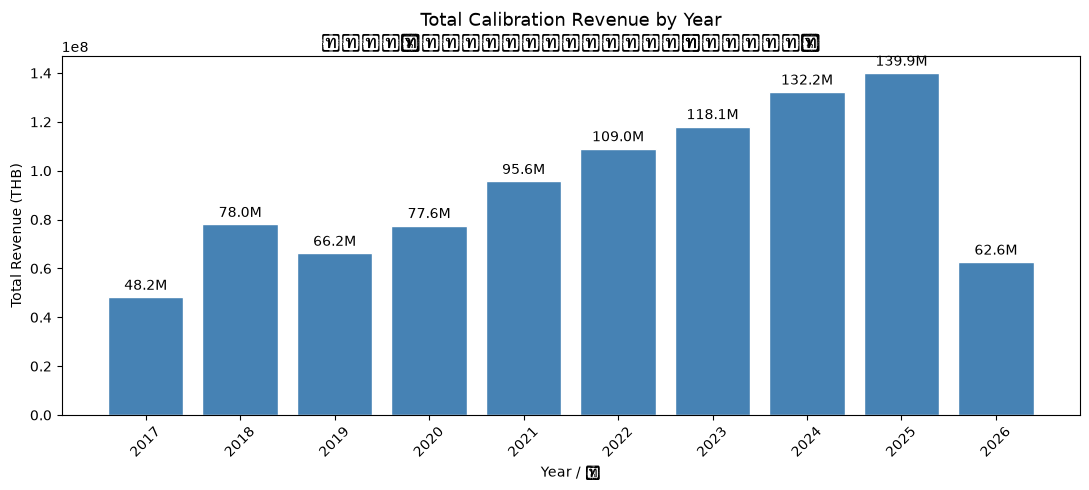


รายได้รายปี / Revenue per year:
 Year  Total_Revenue
 2017    48189193.20
 2018    78017290.28
 2019    66197044.98
 2020    77564112.37
 2021    95604906.84
 2022   109010194.37
 2023   118071031.39
 2024   132217995.09
 2025   139936307.34
 2026    62575990.64


In [12]:
# ✅ Solution — Section 4.1: Yearly Revenue Trend
yearly = df.groupby('RECV_YEAR')['TOTALFEE'].sum().reset_index()
yearly.columns = ['Year', 'Total_Revenue']
yearly = yearly[yearly['Year'].between(2017, 2026)]  # กรองเฉพาะปีที่สมเหตุสมผล

plt.figure(figsize=(11, 5))
bars = plt.bar(yearly['Year'], yearly['Total_Revenue'], color='steelblue', edgecolor='white')
plt.bar_label(bars, labels=[f'{v/1e6:.1f}M' for v in yearly['Total_Revenue']], padding=3)
plt.title('Total Calibration Revenue by Year\nรายได้รวมจากการสอบเทียบรายปี', fontsize=13)
plt.xlabel('Year / ปี')
plt.ylabel('Total Revenue (THB)')
plt.xticks(yearly['Year'], rotation=45)
plt.tight_layout()
plt.show()

print("\nรายได้รายปี / Revenue per year:")
print(yearly.to_string(index=False))

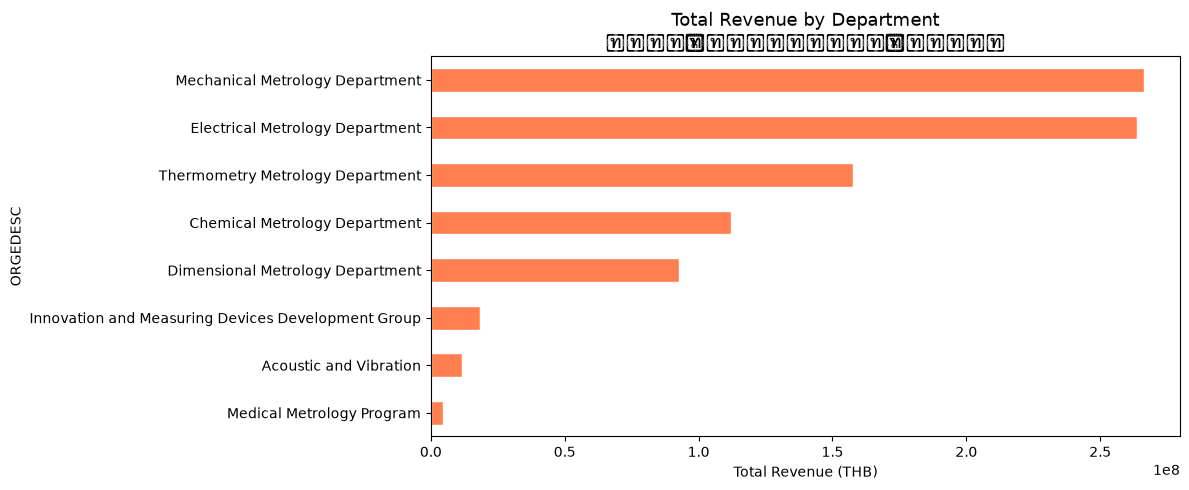


รายได้ตามฝ่ายงาน / Revenue by department:
                                                        TOTALFEE
ORGEDESC                                                        
Mechanical Metrology Department                     2.664720e+08
Electrical Metrology Department                     2.637772e+08
Thermometry Metrology Department                    1.575748e+08
Chemical Metrology Department                       1.122584e+08
Dimensional Metrology Department                    9.273820e+07
Innovation and Measuring Devices Development Group  1.830071e+07
Acoustic and Vibration                              1.170026e+07
Medical Metrology Program                           4.562524e+06


In [13]:
# ✅ Solution — Section 4.2: Revenue by Department
dept_rev = df.groupby('ORGEDESC')['TOTALFEE'].sum().sort_values(ascending=True)

plt.figure(figsize=(12, 5))
dept_rev.plot(kind='barh', color='coral', edgecolor='white')
plt.title('Total Revenue by Department\nรายได้รวมแยกตามฝ่ายงาน', fontsize=13)
plt.xlabel('Total Revenue (THB)')
plt.tight_layout()
plt.show()

print("\nรายได้ตามฝ่ายงาน / Revenue by department:")
print(dept_rev.sort_values(ascending=False).to_frame())

จำนวนงานตามประเภทบริการ / Job count by service type:
SERVICE
Measurement at NIMT    45405
Reference Materials    12190
On site                 3679
Unknown                   12
Name: count, dtype: int64


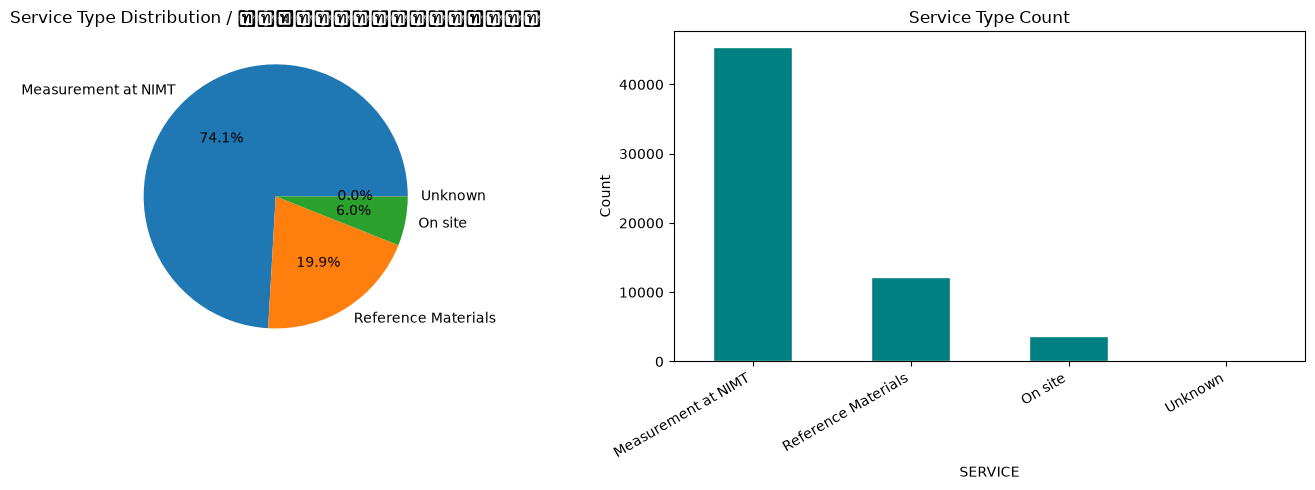

In [14]:
# ✅ Solution — Section 4.3: Service Type Distribution
svc_counts = df['SERVICE'].value_counts()
print("จำนวนงานตามประเภทบริการ / Job count by service type:")
print(svc_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
svc_counts.plot(kind='pie', autopct='%1.1f%%', ax=axes[0])
axes[0].set_title('Service Type Distribution / สัดส่วนประเภทบริการ')
axes[0].set_ylabel('')

svc_counts.plot(kind='bar', ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title('Service Type Count')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(svc_counts.index, rotation=30, ha='right')

plt.tight_layout()
plt.show()

---
## 🔍 ส่วนที่ 5: ค้นหาข้อพิรุธ / Section 5: Anomaly Detection

In [15]:
# ✅ Solution — Section 5.1: Revenue Leakage
leakage = df[(df['IN_OUT'] == 'OUT') & (df['TOTALFEE'] == 0)]
print(f"🚨 จำนวนรายการรายได้รั่วไหล / Revenue leakage rows: {len(leakage):,}")
print(f"💰 มูลค่าที่ควรเรียกเก็บแต่ไม่ได้รับ / Estimated revenue lost: 0 THB (already 0)")
print(f"   แต่จำนวนรายการที่พลาด / But # of uncharged jobs: {len(leakage):,}")

print("\n🔑 Top 10 เครื่องมือที่เกิดการรั่วไหลบ่อยสุด / Top 10 instruments with leakage:")
display(leakage['DESCRIPTION'].value_counts().head(10).to_frame())

print("\n🏢 ฝ่ายงานที่มีการรั่วไหลมากสุด / Departments with most leakage:")
display(leakage['ORGEDESC'].value_counts().to_frame())

🚨 จำนวนรายการรายได้รั่วไหล / Revenue leakage rows: 560
💰 มูลค่าที่ควรเรียกเก็บแต่ไม่ได้รับ / Estimated revenue lost: 0 THB (already 0)
   แต่จำนวนรายการที่พลาด / But # of uncharged jobs: 560

🔑 Top 10 เครื่องมือที่เกิดการรั่วไหลบ่อยสุด / Top 10 instruments with leakage:


,count
DESCRIPTION,
กล้องตรวจจับความเร็วชนิดมือถือ LIDAR SPEED GUN,90
Infusion Pump Analyzer,51
Vital Signs Simulator,49
Gas Flow Analyzer,30
NIBP Simulator,26
RPM Meter,14
Ventilator Analyzer,9
Weight,7
Sound Calibrator type 1251,7



🏢 ฝ่ายงานที่มีการรั่วไหลมากสุด / Departments with most leakage:


,count
ORGEDESC,
Medical Metrology Program,278
Dimensional Metrology Department,117
Mechanical Metrology Department,70
Acoustic and Vibration,40
Thermometry Metrology Department,23
Chemical Metrology Department,22
Electrical Metrology Department,10


⏰ งานที่ใช้เวลา > 365 วัน / Jobs > 365 days: 210
📅 จำนวนวันสูงสุด / Max days: 1,614 days
📅 ค่าเฉลี่ย / Mean days: 42.3 days


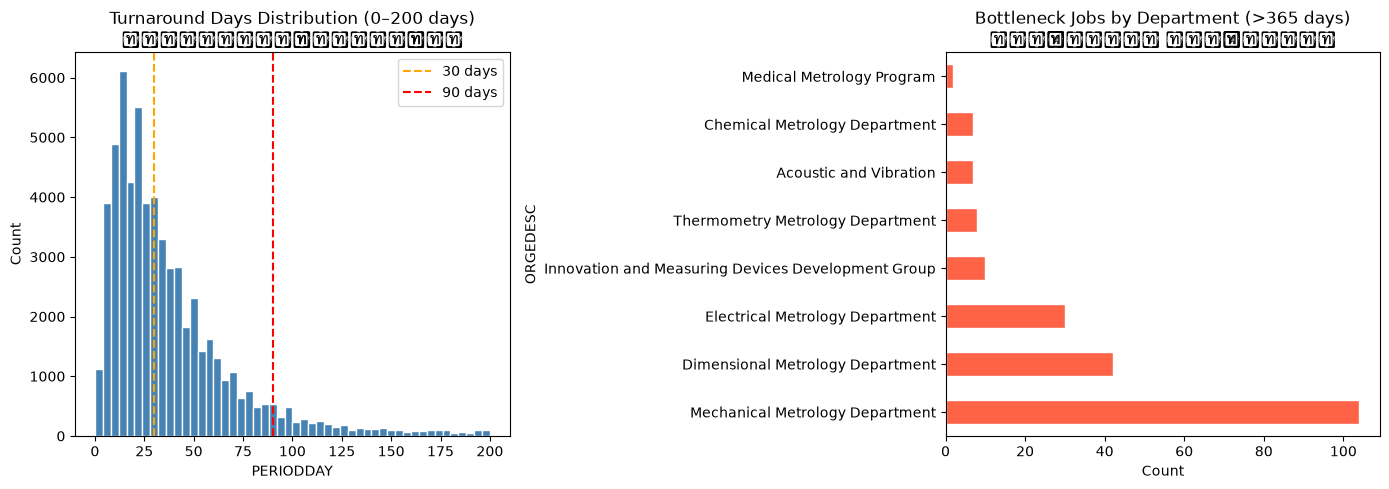

In [16]:
# ✅ Solution — Section 5.2: Turnaround Bottleneck
bottleneck = df[df['PERIODDAY'] > 365]
print(f"⏰ งานที่ใช้เวลา > 365 วัน / Jobs > 365 days: {len(bottleneck):,}")
print(f"📅 จำนวนวันสูงสุด / Max days: {df['PERIODDAY'].max():,} days")
print(f"📅 ค่าเฉลี่ย / Mean days: {df['PERIODDAY'].mean():.1f} days")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram ทั้งหมด
axes[0].hist(df[df['PERIODDAY'].between(0, 200)]['PERIODDAY'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Turnaround Days Distribution (0–200 days)\nการกระจายวันสอบเทียบ')
axes[0].set_xlabel('PERIODDAY')
axes[0].set_ylabel('Count')
axes[0].axvline(30, color='orange', linestyle='--', label='30 days')
axes[0].axvline(90, color='red', linestyle='--', label='90 days')
axes[0].legend()

# งาน bottleneck ตามฝ่ายงาน
dept_bottleneck = bottleneck['ORGEDESC'].value_counts()
dept_bottleneck.plot(kind='barh', ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title('Bottleneck Jobs by Department (>365 days)\nงานค้างนาน ตามฝ่ายงาน')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

---
## 🤖 ส่วนที่ 6: K-Means Clustering พร้อม PCA / Section 6: K-Means + PCA

In [17]:
# ✅ Solution — Section 6.1: Select Features & Scale
df_cluster = df[(df['TOTALFEE'] > 0) & (df['PERIODDAY'] > 0)].copy()

features = ['TOTALFEE', 'PERIODDAY']
X = df_cluster[features].dropna()

# StandardScaler: ทำให้แต่ละ feature มีค่าเฉลี่ย 0 และ SD 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"✅ Features selected: {features}")
print(f"Data shape after filtering & scaling: {X_scaled.shape}")
print(f"\nMeans (before scaling): {X.mean().to_dict()}")
print(f"Means (after scaling):  {X_scaled.mean(axis=0).round(5)}  ← should be ~0")

✅ Features selected: ['TOTALFEE', 'PERIODDAY']
Data shape after filtering & scaling: (60233, 2)

Means (before scaling): {'TOTALFEE': 15347.038442382083, 'PERIODDAY': 42.22515896601531}
Means (after scaling):  [-0.  0.]  ← should be ~0


=== PCA Results ===
Explained Variance Ratio per PC: [0.55850113 0.44149887]
Total Explained Variance: 100.0%


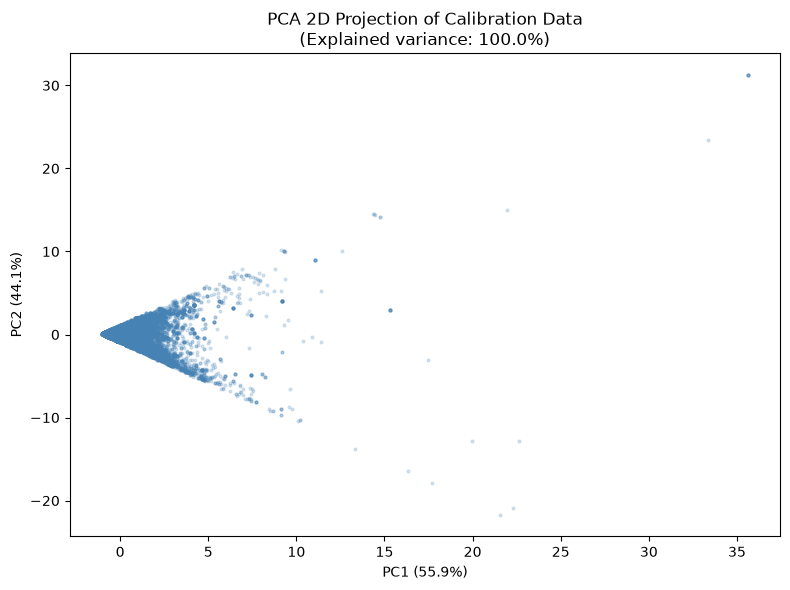

In [18]:
# ✅ Solution — Section 6.2: PCA — Dimensionality Reduction
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("=== PCA Results ===")
print(f"Explained Variance Ratio per PC: {pca.explained_variance_ratio_}")
print(f"Total Explained Variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# PCA biplot / scatter
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.2, s=4, color='steelblue')
plt.title(
    f'PCA 2D Projection of Calibration Data\n'
    f'(Explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%)'
)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.tight_layout()
plt.show()

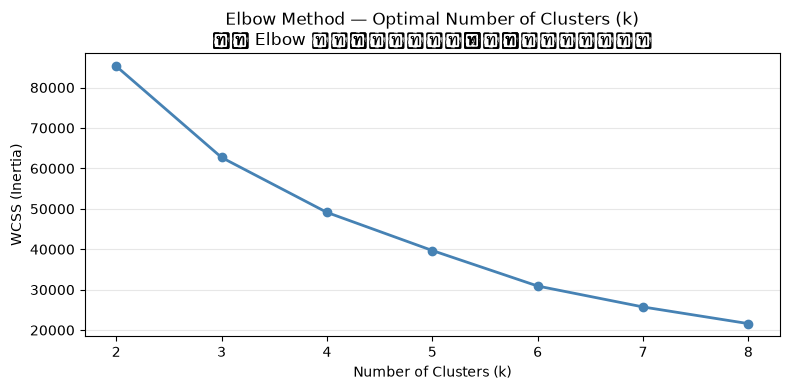


WCSS values by k:
  k=2: 85,284
  k=3: 62,708
  k=4: 49,116
  k=5: 39,693
  k=6: 30,906
  k=7: 25,731
  k=8: 21,606


In [19]:
# ✅ Solution — Section 6.3: Elbow Method
wcss = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, wcss, marker='o', linewidth=2, color='steelblue')
plt.title('Elbow Method — Optimal Number of Clusters (k)\nวิธี Elbow หาจำนวนกลุ่มที่เหมาะสม')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nWCSS values by k:")
for k, w in zip(k_range, wcss):
    print(f"  k={k}: {w:,.0f}")

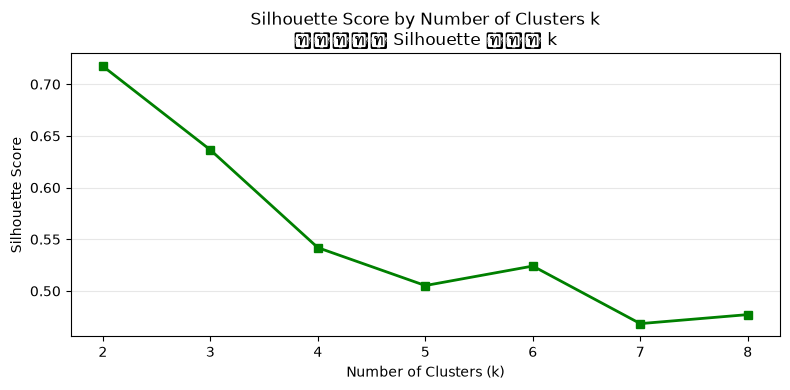


✅ Best k by Silhouette Score: k=2 (score=0.7174)


In [20]:
# ✅ Solution — Section 6.4: Silhouette Score
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8, 4))
plt.plot(k_range, sil_scores, marker='s', linewidth=2, color='green')
plt.title('Silhouette Score by Number of Clusters k\nคะแนน Silhouette ตาม k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

best_k = list(k_range)[sil_scores.index(max(sil_scores))]
print(f"\n✅ Best k by Silhouette Score: k={best_k} (score={max(sil_scores):.4f})")

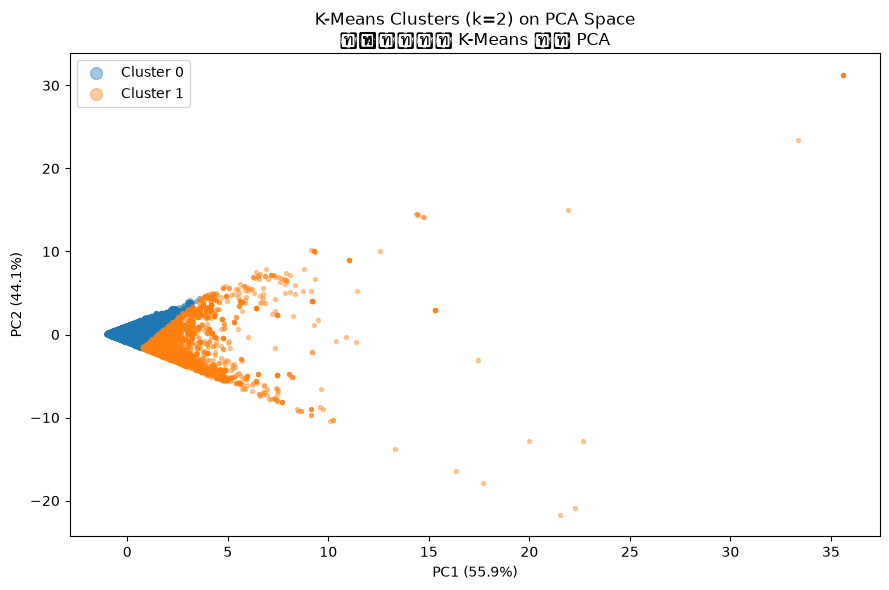


📊 Cluster Characteristics (mean values):


,TOTALFEE,PERIODDAY
Cluster,,
0,13849.0,33.0
1,37364.0,184.0


In [21]:
# ✅ Solution — Section 6.5: Final K-Means + PCA plot
BEST_K = best_k  # ใช้ค่าที่ได้จาก Silhouette / Use best k from Silhouette

km_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
# ต้องใช้ X_scaled ของ df_cluster ที่ dropna แล้ว
cluster_labels = km_final.fit_predict(X_scaled)
df_cluster = df_cluster.loc[X.index].copy()
df_cluster['Cluster'] = cluster_labels

# วาดบน PCA space
colors = plt.cm.tab10.colors
plt.figure(figsize=(9, 6))
for c in range(BEST_K):
    mask = cluster_labels == c
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        label=f'Cluster {c}', alpha=0.4, s=8, color=colors[c]
    )
plt.title(f'K-Means Clusters (k={BEST_K}) on PCA Space\nกลุ่มของ K-Means บน PCA')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()

# สรุปค่าเฉลี่ยต่อกลุ่ม / Cluster summary
print("\n📊 Cluster Characteristics (mean values):")
display(df_cluster.groupby('Cluster')[['TOTALFEE', 'PERIODDAY']].mean().round(0))

---
## 📊 ส่วนที่ 7: พยากรณ์รายได้ / Section 7: Revenue Forecasting

Monthly data rows: 110
   Year  Month    Revenue   t
0  2017      3  2352936.0   1
1  2017      4  2872032.0   2
2  2017      5  4008685.0   3
3  2017      6  4154387.0   4
4  2017      7  3166216.2   5
5  2017      8  4203563.0   6
6  2017      9  3038708.0   7
7  2017     10  4820417.0   8
8  2017     11  3152035.0   9
9  2017     12  2541625.0  10


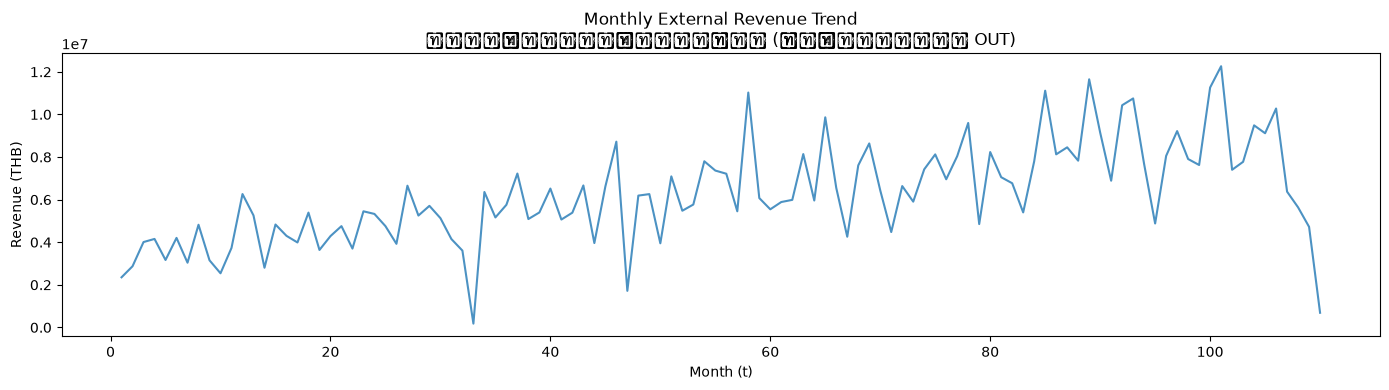

In [22]:
# ✅ Solution — Section 7.1: Prepare monthly revenue data
monthly = df[(df['IN_OUT'] == 'OUT') & (df['TOTALFEE'] > 0)].groupby(
    ['RECV_YEAR', 'RECV_MONTH']
)['TOTALFEE'].sum().reset_index()
monthly.columns = ['Year', 'Month', 'Revenue']

monthly = monthly.sort_values(['Year', 'Month']).reset_index(drop=True)
monthly['t'] = range(1, len(monthly) + 1)  # t = sequential month index

print(f"Monthly data rows: {len(monthly)}")
print(monthly.head(10))

# วาดกราฟรายได้รายเดือน
plt.figure(figsize=(14, 4))
plt.plot(monthly['t'], monthly['Revenue'], alpha=0.8)
plt.title('Monthly External Revenue Trend\nแนวโน้มรายได้รายเดือน (ลูกค้าภายนอก OUT)')
plt.xlabel('Month (t)')
plt.ylabel('Revenue (THB)')
plt.tight_layout()
plt.show()

Linear Regression — R²: -0.1683 | MAE: 2,142,904 THB
Trend slope: 52,618 THB/month | Intercept: 3,390,096 THB


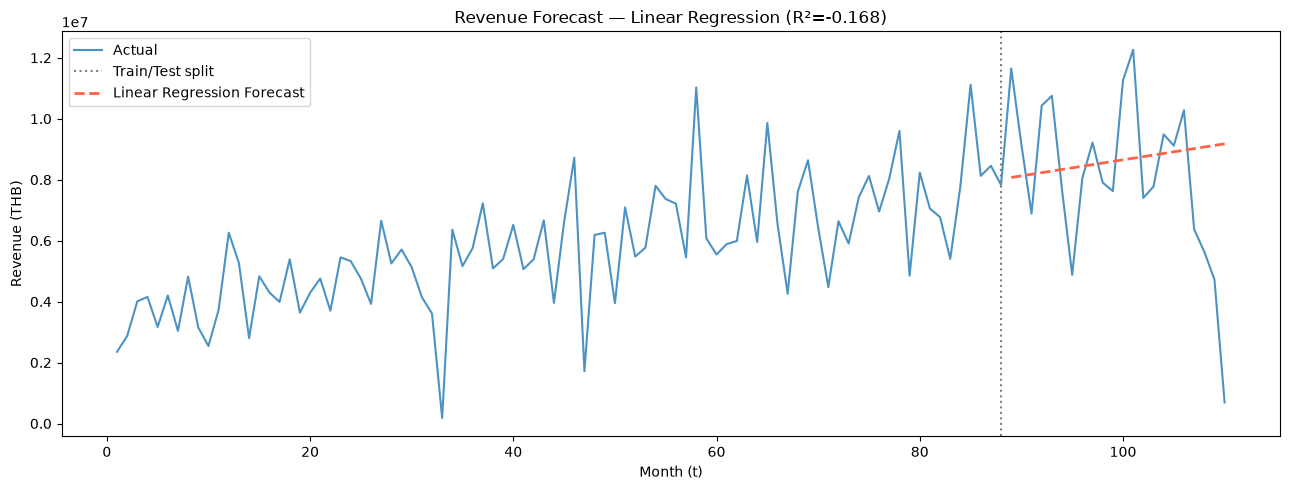

In [23]:
# ✅ Solution — Section 7.2: Linear Regression Forecast
X_lr = monthly[['t']]
y_lr = monthly['Revenue']

# แบ่ง 80% train / 20% test (ไม่สุ่มเพื่อรักษาลำดับเวลา / no shuffle to keep time order)
X_train, X_test, y_train, y_test = train_test_split(X_lr, y_lr, test_size=0.2, shuffle=False)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

lr_r2  = r2_score(y_test, y_pred_lr)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
print(f"Linear Regression — R²: {lr_r2:.4f} | MAE: {lr_mae:,.0f} THB")
print(f"Trend slope: {lr.coef_[0]:,.0f} THB/month | Intercept: {lr.intercept_:,.0f} THB")

# วาดผล
plt.figure(figsize=(13, 5))
plt.plot(monthly['t'], monthly['Revenue'], label='Actual', alpha=0.8)
plt.axvline(X_train['t'].max(), color='grey', linestyle=':', label='Train/Test split')
plt.plot(X_test['t'].values, y_pred_lr, label='Linear Regression Forecast',
         linestyle='--', linewidth=2, color='tomato')
plt.title(f'Revenue Forecast — Linear Regression (R²={lr_r2:.3f})')
plt.xlabel('Month (t)')
plt.ylabel('Revenue (THB)')
plt.legend()
plt.tight_layout()
plt.show()

Random Forest — R²: -0.0581 | MAE: 1,998,095 THB


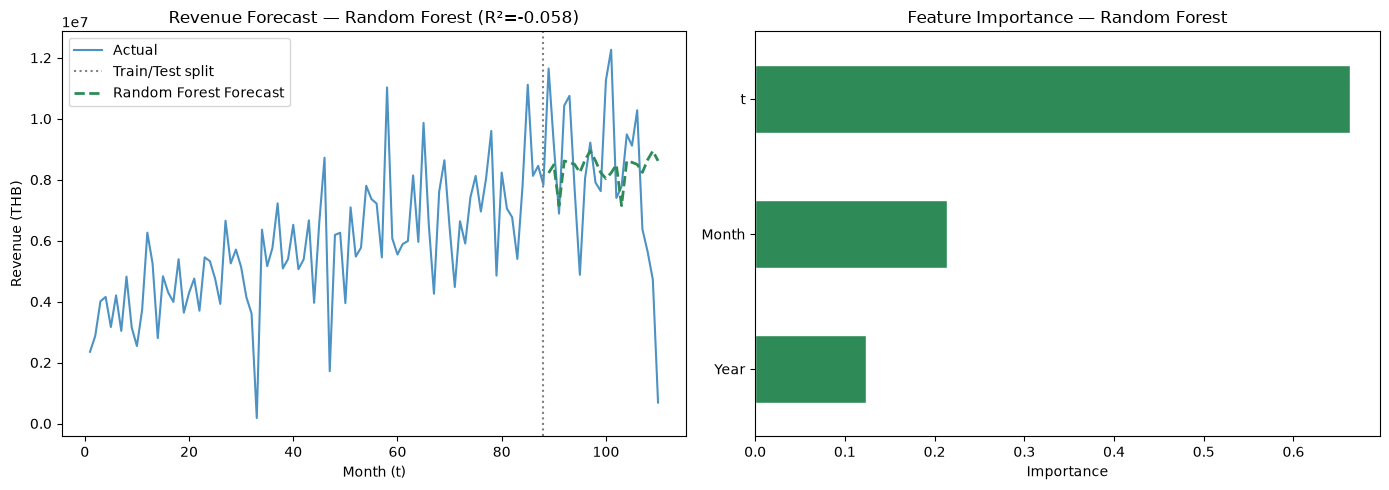

In [24]:
# ✅ Solution — Section 7.3: Random Forest Regressor Forecast
X_rf = monthly[['t', 'Year', 'Month']]
y_rf = monthly['Revenue']

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf, test_size=0.2, shuffle=False
)

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_rf, y_train_rf)
y_pred_rf = rf.predict(X_test_rf)

rf_r2  = r2_score(y_test_rf, y_pred_rf)
rf_mae = mean_absolute_error(y_test_rf, y_pred_rf)
print(f"Random Forest — R²: {rf_r2:.4f} | MAE: {rf_mae:,.0f} THB")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Forecast plot
axes[0].plot(monthly['t'], monthly['Revenue'], label='Actual', alpha=0.8)
axes[0].axvline(X_train_rf['t'].max(), color='grey', linestyle=':', label='Train/Test split')
axes[0].plot(X_test_rf['t'].values, y_pred_rf,
             label='Random Forest Forecast', linestyle='--', linewidth=2, color='seagreen')
axes[0].set_title(f'Revenue Forecast — Random Forest (R²={rf_r2:.3f})')
axes[0].set_xlabel('Month (t)')
axes[0].set_ylabel('Revenue (THB)')
axes[0].legend()

# Feature Importance
importances = pd.Series(rf.feature_importances_, index=X_rf.columns).sort_values()
importances.plot(kind='barh', ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('Feature Importance — Random Forest')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

In [25]:
# ✅ Solution — Section 7.4: Model Comparison Table
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R²':  [lr_r2, rf_r2],
    'MAE (THB)': [lr_mae, rf_mae]
})
results['R²'] = results['R²'].round(4)
results['MAE (THB)'] = results['MAE (THB)'].round(0).astype(int)
display(results)

winner = results.loc[results['R²'].idxmax(), 'Model']
print(f"\n🏆 ชนะ: {winner} (R² สูงกว่า = อธิบายความแปรปรวนได้มากกว่า)")
print(f"   Winner: {winner} (higher R² = explains more variance)")

,Model,R²,MAE (THB)
0,Linear Regression,-0.1683,2142904
1,Random Forest,-0.0581,1998095



🏆 ชนะ: Random Forest (R² สูงกว่า = อธิบายความแปรปรวนได้มากกว่า)
   Winner: Random Forest (higher R² = explains more variance)


---
## 🏁 สรุปผลการวิเคราะห์ / Analysis Summary

| หัวข้อ | ผลที่ได้ |
|---|---|
| **ขนาดข้อมูล** | ~61,286 รายการ, 10 คอลัมน์ |
| **BUG-002** | ชื่อฝ่ายงานมีช่องว่างซ้ำซ้อน → แก้ไขด้วย `str.replace(r'  +', ' ')` |
| **Revenue Leakage** | งาน OUT ที่ TOTALFEE=0 → ควรตรวจสอบนโยบายเรียกเก็บเงิน |
| **Bottleneck** | บางงานใช้เวลาสูงสุด 1,614 วัน → ควรตรวจสอบ workflow |
| **Clustering** | K-Means แบ่งกลุ่มงานตาม fee/time → ใช้วางแผน resource |
| **PCA** | ลดมิติเพื่อ visualize clusters ใน 2D |
| **Linear Regression** | พยากรณ์แนวโน้มรายได้ระยะยาว |
| **Random Forest** | พยากรณ์แบบ ensemble — มักแม่นกว่า LR |

📂 **ต้องการฝึกหัด?** เปิดไฟล์ `nimt_eda_exercise.ipynb` และลองเติมโค้ดด้วยตัวเอง!  
📂 **Want to practice?** Open `nimt_eda_exercise.ipynb` and fill in the code yourself!